In [ ]:
 #to prevent colab to automatically disconnect
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button")
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click()
     }

   btn = document.getElementById('ok')
   if (btn != null){
     console.log("Click reconnect");
     btn.click()
     }
  }

setInterval(ClickConnect,60000)
'''))

print("Done.")

<IPython.core.display.Javascript object>

Done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Step 1 : Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

In [ ]:
patrol_divisons = {1: 'Central',
 2: 'Rampart',
 3: 'Southwest',
 4: 'Hollenbeck',
 5: 'Harbor',
 6: 'Hollywood',
 7: 'Wilshire',
 8: 'West LA',
 9: 'Van Nuys',
 10: 'West Valley',
 11: 'Northeast',
 12: '77th Street',
 13: 'Newton',
 14: 'Pacific',
 15: 'N Hollywood',
 16: 'Foothill',
 17: 'Devonshire',
 18: 'Southeast',
 19: 'Mission',
 20: 'Olympic',
 21: 'Topanga'}



# **SATEP 1 : Loading Result Files**

In [ ]:
bi_lstm_results_csv_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi LSTM/mh_attn_bi_lstm_metrics_1.csv'
bi_gru_results_csv_path  = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/mh_attn_bi_gru_results_1.csv'
cnn_bi_gru_results_csv_path  = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/mh_attn_bi_cnn_gru_results_1.csv'

In [ ]:
bi_lstm_result = pd.read_csv(bi_lstm_results_csv_path)
bi_gru_result = pd.read_csv(bi_gru_results_csv_path)
cnn_bi_gru_result = pd.read_csv(cnn_bi_gru_results_csv_path)

In [ ]:
columns = bi_lstm_result.columns
columns

Index(['Division', 'test rmse', 'test mae', 'val rmse', 'val mae'], dtype='object')

In [ ]:
bi_gru_result.head(21)

,Division,test rmse,test mae,val rmse,val mae
0,Central,0.713613,0.223138,0.476545,0.184686
1,Rampart,0.403934,0.101825,0.308708,0.094344
2,Southwest,0.363826,0.115266,0.484089,0.121378
3,Hollenbeck,0.184826,0.061920,0.237104,0.070740
4,Harbor,0.194902,0.054310,0.246436,0.061823
5,Hollywood,0.250244,0.065559,0.304336,0.083097
6,Wilshire,0.227689,0.051474,0.265104,0.065106
7,West LA,0.202879,0.045108,0.256146,0.062406
8,Van Nuys,0.197093,0.045592,0.232320,0.055161
9,West Valley,0.200406,0.046906,0.247521,0.058092


In [ ]:
cnn_bi_gru_result.head(21)

,Division,test rmse,test mae,val rmse,val mae
0,Central,0.734771,0.220938,0.502036,0.183389
1,Rampart,0.416581,0.107550,0.315990,0.092293
2,Southwest,0.392695,0.139872,0.517011,0.139608
3,Hollenbeck,0.186770,0.055708,0.240148,0.068322
4,Harbor,0.206728,0.061339,0.253156,0.070763
5,Hollywood,0.264965,0.081471,0.310172,0.100009
6,Wilshire,0.298715,0.110663,0.335209,0.132374
7,West LA,0.213828,0.060957,0.264133,0.083430
8,Van Nuys,0.209289,0.063126,0.244397,0.075294
9,West Valley,0.207974,0.060079,0.259444,0.077380


In [ ]:
bi_lstm_result.head(21)

,Division,test rmse,test mae,val rmse,val mae
0,Central,0.747138,0.231611,0.533995,0.213056
1,Rampart,0.442736,0.114495,0.365743,0.120840
2,Southwest,0.384467,0.112412,0.503740,0.128599
3,Hollenbeck,0.213087,0.056105,0.276496,0.076320
4,Harbor,0.240912,0.058873,0.285419,0.075972
5,Hollywood,0.297281,0.082892,0.362755,0.115264
6,Wilshire,0.271196,0.073144,0.319655,0.095985
7,West LA,0.232333,0.056557,0.302925,0.087338
8,Van Nuys,0.220680,0.054640,0.272708,0.074478
9,West Valley,0.221954,0.055003,0.289845,0.080106


Merging Result Files

In [ ]:
# Rename columns to reflect the model names before merging
bi_gru_result_renamed = bi_gru_result.rename(columns={
    'test rmse': 'bi_gru_test_rmse',
    'test mae': 'bi_gru_test_mae',
    'val rmse': 'bi_gru_val_rmse',
    'val mae': 'bi_gru_val_mae'
})

bi_lstm_result_renamed = bi_lstm_result.rename(columns={
    'test rmse': 'bi_lstm_test_rmse',
    'test mae': 'bi_lstm_test_mae',
    'val rmse': 'bi_lstm_val_rmse',
    'val mae': 'bi_lstm_val_mae'
})

cnn_bi_gru_result_renamed = cnn_bi_gru_result.rename(columns={
    'test rmse': 'cnn_bi_gru_test_rmse',
    'test mae': 'cnn_bi_gru_test_mae',
    'val rmse': 'cnn_bi_gru_val_rmse',
    'val mae': 'cnn_bi_gru_val_mae'
})

# Now merge all three on 'Division'
results = bi_gru_result_renamed.merge(
    bi_lstm_result_renamed, on="Division"
).merge(
    cnn_bi_gru_result_renamed, on="Division"
)

# Show the merged results
results.head()


,Division,bi_gru_test_rmse,bi_gru_test_mae,bi_gru_val_rmse,bi_gru_val_mae,bi_lstm_test_rmse,bi_lstm_test_mae,bi_lstm_val_rmse,bi_lstm_val_mae,cnn_bi_gru_test_rmse,cnn_bi_gru_test_mae,cnn_bi_gru_val_rmse,cnn_bi_gru_val_mae
0,Central,0.713613,0.223138,0.476545,0.184686,0.747138,0.231611,0.533995,0.213056,0.734771,0.220938,0.502036,0.183389
1,Rampart,0.403934,0.101825,0.308708,0.094344,0.442736,0.114495,0.365743,0.120840,0.416581,0.107550,0.315990,0.092293
2,Southwest,0.363826,0.115266,0.484089,0.121378,0.384467,0.112412,0.503740,0.128599,0.392695,0.139872,0.517011,0.139608
3,Hollenbeck,0.184826,0.061920,0.237104,0.070740,0.213087,0.056105,0.276496,0.076320,0.186770,0.055708,0.240148,0.068322
4,Harbor,0.194902,0.054310,0.246436,0.061823,0.240912,0.058873,0.285419,0.075972,0.206728,0.061339,0.253156,0.070763


**Separating Into Test and Validation Result Files**

In [ ]:
test_metrics_df = results[['Division', 'bi_gru_test_rmse', 'bi_lstm_test_rmse', 'cnn_bi_gru_test_rmse','bi_gru_test_mae', 'bi_lstm_test_mae', 'cnn_bi_gru_test_mae']]
val_metrics_df = results[['Division', 'bi_gru_val_rmse', 'bi_lstm_val_rmse', 'cnn_bi_gru_val_rmse','bi_gru_val_mae','bi_lstm_val_mae','cnn_bi_gru_val_mae']]

In [ ]:
test_metrics_df

,Division,bi_gru_test_rmse,bi_lstm_test_rmse,cnn_bi_gru_test_rmse,bi_gru_test_mae,bi_lstm_test_mae,cnn_bi_gru_test_mae
0,Central,0.713613,0.747138,0.734771,0.223138,0.231611,0.220938
1,Rampart,0.403934,0.442736,0.416581,0.101825,0.114495,0.107550
2,Southwest,0.363826,0.384467,0.392695,0.115266,0.112412,0.139872
3,Hollenbeck,0.184826,0.213087,0.186770,0.061920,0.056105,0.055708
4,Harbor,0.194902,0.240912,0.206728,0.054310,0.058873,0.061339
5,Hollywood,0.250244,0.297281,0.264965,0.065559,0.082892,0.081471
6,Wilshire,0.227689,0.271196,0.298715,0.051474,0.073144,0.110663
7,West LA,0.202879,0.232333,0.213828,0.045108,0.056557,0.060957
8,Van Nuys,0.197093,0.220680,0.209289,0.045592,0.054640,0.063126
9,West Valley,0.200406,0.221954,0.207974,0.046906,0.055003,0.060079


**Listing out models which performed well in each City**

In [ ]:
#based on test rmse and mae
best_model_rmse = []
best_model_mae = []
divisons = test_metrics_df.values
for i in divisons:
   if (i[1] < i[2] and i[1] < i[3]):
      best_model_rmse.append("bi_gru")
   elif(i[2]<i[1] and i[2]<i[3]):
      best_model_rmse.append("bi_lstm")
   else:
      best_model_rmse.append("cnn_bi_gru")

for i in divisons:
   if (i[4] < i[5] and i[4] < i[6]):
      best_model_mae.append("bi_gru")
   elif(i[5]<i[4] and i[5]<i[6]):
      best_model_mae.append("bi_lstm")
   else:
      best_model_mae.append("cnn_bi_gru")

test_metrics_df["Best Model(based on test rmse)"] = best_model_rmse
test_metrics_df['Best Model(based on test mae)'] = best_model_mae
test_metrics_df.head(21)

<ipython-input-23-965888dcb228>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_metrics_df["Best Model(based on test rmse)"] = best_model_rmse
<ipython-input-23-965888dcb228>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_metrics_df['Best Model(based on test mae)'] = best_model_mae


,Division,bi_gru_test_rmse,bi_lstm_test_rmse,cnn_bi_gru_test_rmse,bi_gru_test_mae,bi_lstm_test_mae,cnn_bi_gru_test_mae,Best Model(based on test rmse),Best Model(based on test mae)
0,Central,0.713613,0.747138,0.734771,0.223138,0.231611,0.220938,bi_gru,cnn_bi_gru
1,Rampart,0.403934,0.442736,0.416581,0.101825,0.114495,0.107550,bi_gru,bi_gru
2,Southwest,0.363826,0.384467,0.392695,0.115266,0.112412,0.139872,bi_gru,bi_lstm
3,Hollenbeck,0.184826,0.213087,0.186770,0.061920,0.056105,0.055708,bi_gru,cnn_bi_gru
4,Harbor,0.194902,0.240912,0.206728,0.054310,0.058873,0.061339,bi_gru,bi_gru
5,Hollywood,0.250244,0.297281,0.264965,0.065559,0.082892,0.081471,bi_gru,bi_gru
6,Wilshire,0.227689,0.271196,0.298715,0.051474,0.073144,0.110663,bi_gru,bi_gru
7,West LA,0.202879,0.232333,0.213828,0.045108,0.056557,0.060957,bi_gru,bi_gru
8,Van Nuys,0.197093,0.220680,0.209289,0.045592,0.054640,0.063126,bi_gru,bi_gru
9,West Valley,0.200406,0.221954,0.207974,0.046906,0.055003,0.060079,bi_gru,bi_gru


In [ ]:
#based on validation rmse and mae
best_model_rmse = []
best_model_mae = []
divisons = val_metrics_df.values
for i in divisons:
   if (i[1] < i[2] and i[1] < i[3]):
      best_model_rmse.append("bi_gru")
   elif(i[2]<i[1] and i[2]<i[3]):
      best_model_rmse.append("bi_lstm")
   else:
      best_model_rmse.append("cnn_bi_gru")

for i in divisons:
   if (i[4] < i[5] and i[4] < i[6]):
      best_model_mae.append("bi_gru")
   elif(i[5]<i[4] and i[5]<i[6]):
      best_model_mae.append("bi_lstm")
   else:
      best_model_mae.append("cnn_bi_gru")

val_metrics_df["Best Model(based on val rmse)"] = best_model_rmse
val_metrics_df["Best Model(based on val mae)"]= best_model_mae
val_metrics_df.head(21)

<ipython-input-24-e797e1f78fd6>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_metrics_df["Best Model(based on val rmse)"] = best_model_rmse
<ipython-input-24-e797e1f78fd6>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_metrics_df["Best Model(based on val mae)"]= best_model_mae


,Division,bi_gru_val_rmse,bi_lstm_val_rmse,cnn_bi_gru_val_rmse,bi_gru_val_mae,bi_lstm_val_mae,cnn_bi_gru_val_mae,Best Model(based on val rmse),Best Model(based on val mae)
0,Central,0.476545,0.533995,0.502036,0.184686,0.213056,0.183389,bi_gru,cnn_bi_gru
1,Rampart,0.308708,0.365743,0.315990,0.094344,0.120840,0.092293,bi_gru,cnn_bi_gru
2,Southwest,0.484089,0.503740,0.517011,0.121378,0.128599,0.139608,bi_gru,bi_gru
3,Hollenbeck,0.237104,0.276496,0.240148,0.070740,0.076320,0.068322,bi_gru,cnn_bi_gru
4,Harbor,0.246436,0.285419,0.253156,0.061823,0.075972,0.070763,bi_gru,bi_gru
5,Hollywood,0.304336,0.362755,0.310172,0.083097,0.115264,0.100009,bi_gru,bi_gru
6,Wilshire,0.265104,0.319655,0.335209,0.065106,0.095985,0.132374,bi_gru,bi_gru
7,West LA,0.256146,0.302925,0.264133,0.062406,0.087338,0.083430,bi_gru,bi_gru
8,Van Nuys,0.232320,0.272708,0.244397,0.055161,0.074478,0.075294,bi_gru,bi_gru
9,West Valley,0.247521,0.289845,0.259444,0.058092,0.080106,0.077380,bi_gru,bi_gru


In [ ]:
#Finding the count of divison in which each performed well
count_in_test_rmse ={'bi_gru':0,'bi_lstm':0,'cnn_bi_gru':0}
count_in_test_mae ={'bi_gru':0,'bi_lstm':0,'cnn_bi_gru':0}
count_in_val_rmse={'bi_gru':0,'bi_lstm':0,'cnn_bi_gru':0}
count_in_val_mae ={'bi_gru':0,'bi_lstm':0,'cnn_bi_gru':0}

for i in range (0,len(test_metrics_df["Best Model(based on test rmse)"])):
    count_in_test_rmse[test_metrics_df["Best Model(based on test rmse)"][i]] += 1

for i in range (0,len(test_metrics_df["Best Model(based on test mae)"])):
    count_in_test_mae[test_metrics_df["Best Model(based on test mae)"][i]] += 1

for i in range (0,len(val_metrics_df["Best Model(based on val rmse)"])):
    count_in_val_rmse[val_metrics_df["Best Model(based on val rmse)"][i]] += 1

for i in range(0,len(val_metrics_df["Best Model(based on val mae)"])):
    count_in_val_mae[val_metrics_df["Best Model(based on val mae)"][i]] += 1

In [ ]:
print(count_in_test_rmse)
print(count_in_test_mae)
print(count_in_val_rmse)
print(count_in_val_mae)

{'bi_gru': 21, 'bi_lstm': 0, 'cnn_bi_gru': 0}
{'bi_gru': 18, 'bi_lstm': 1, 'cnn_bi_gru': 2}
{'bi_gru': 21, 'bi_lstm': 0, 'cnn_bi_gru': 0}
{'bi_gru': 18, 'bi_lstm': 0, 'cnn_bi_gru': 3}


**1.Bar Plot(to visualize in how many cities each model performed well)**

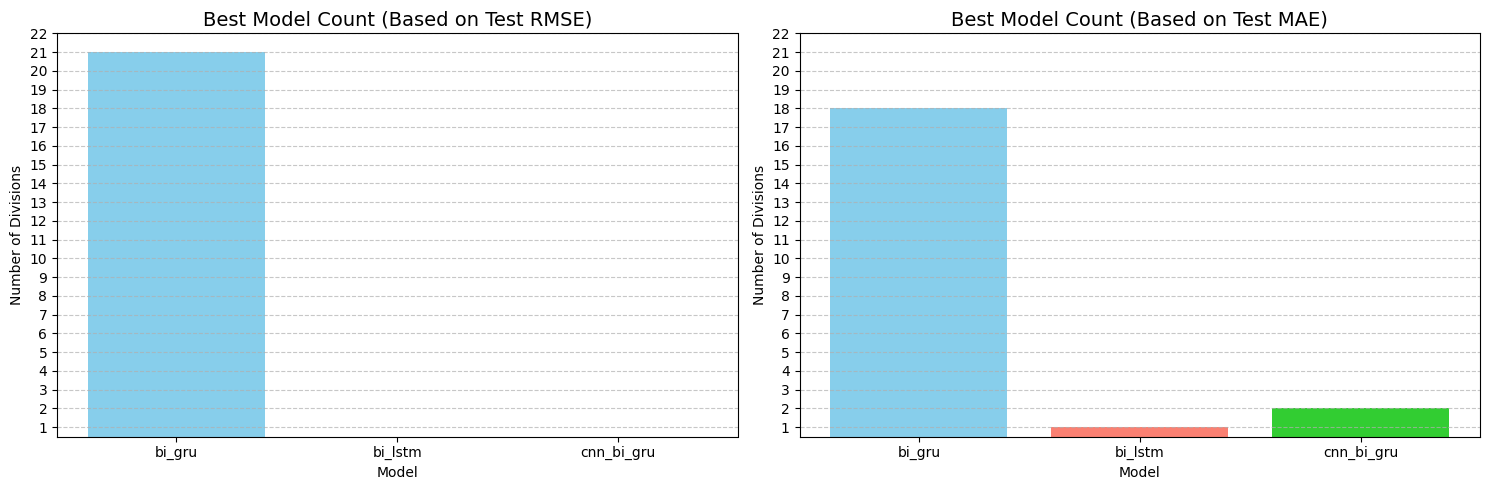

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot RMSE-based bar plot
axs[0].bar(count_in_test_rmse.keys(), count_in_test_rmse.values(), color=['skyblue', 'salmon', 'limegreen'])
axs[0].set_title("Best Model Count (Based on Test RMSE)", fontsize=14)
axs[0].set_xlabel("Model")
axs[0].set_ylabel("Number of Divisions")
axs[0].set_ylim(0.5, 22)
axs[0].yaxis.set_major_locator(MultipleLocator(1))  # Force integer ticks
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot MAE-based bar plot
axs[1].bar(count_in_test_mae.keys(), count_in_test_mae.values(), color=['skyblue', 'salmon', 'limegreen'])
axs[1].set_title("Best Model Count (Based on Test MAE)", fontsize=14)
axs[1].set_xlabel("Model")
axs[1].set_ylabel("Number of Divisions")
axs[1].set_ylim(0.5, 22)
axs[1].yaxis.set_major_locator(MultipleLocator(1))  # Force integer ticks
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


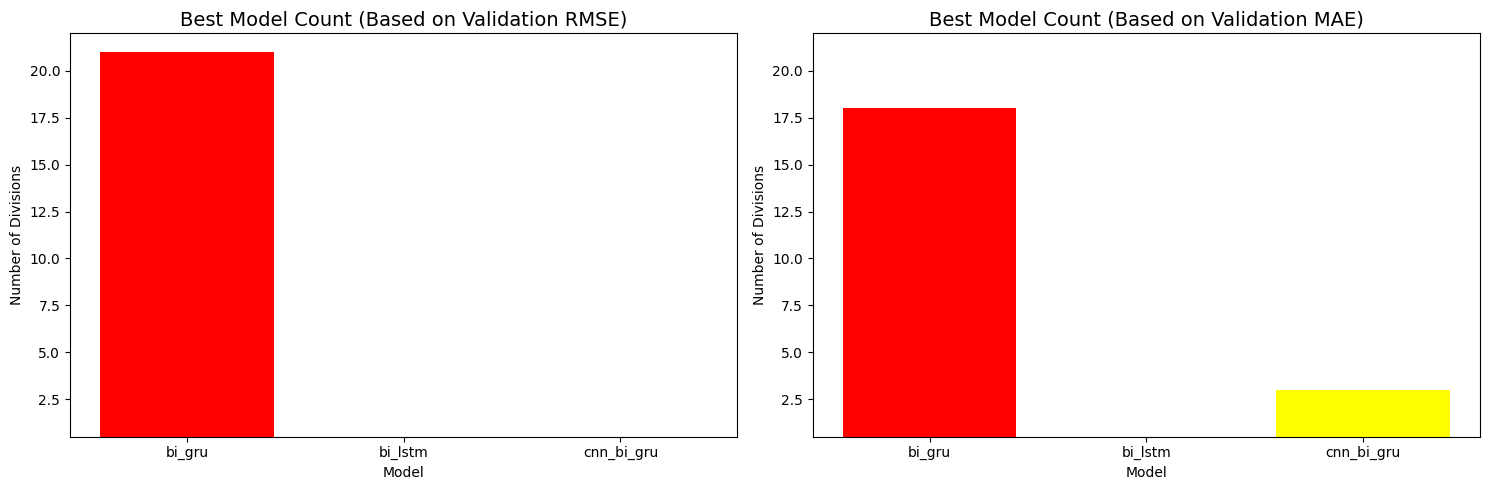

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot RMSE-based bar plot
axs[0].bar(count_in_val_rmse.keys(), count_in_val_rmse.values(), color=['red', 'green', 'yellow'])
axs[0].set_title("Best Model Count (Based on Validation RMSE)", fontsize=14)
axs[0].set_xlabel("Model")
axs[0].set_ylabel("Number of Divisions")
axs[0].set_ylim(0.5, 22)

# Plot MAE-based bar plot
axs[1].bar(count_in_val_mae.keys(), count_in_val_mae.values(), color=['red', 'green', 'yellow'])
axs[1].set_title("Best Model Count (Based on Validation MAE)", fontsize=14)
axs[1].set_xlabel("Model")
axs[1].set_ylabel("Number of Divisions")
axs[1].set_ylim(0.5, 22)


plt.tight_layout()
plt.show()


**2.Box Plot(to visualize the distribution of test rmse, test mae, val rmse , val mae of each model)**

In [ ]:
# Prepare data
test_rmse_df = pd.DataFrame({
    'Division': test_metrics_df['Division'],
    'BiGRU': test_metrics_df['bi_gru_test_rmse'],
    'BiLSTM': test_metrics_df['bi_lstm_test_rmse'],
    'CNN-BiGRU': test_metrics_df['cnn_bi_gru_test_rmse']
})

test_mae_df = pd.DataFrame({
    'Division': test_metrics_df['Division'],
    'BiGRU': test_metrics_df['bi_gru_test_mae'],
    'BiLSTM': test_metrics_df['bi_lstm_test_mae'],
    'CNN-BiGRU': test_metrics_df['cnn_bi_gru_test_mae']
})


val_rmse_df = pd.DataFrame({
    'Division': val_metrics_df['Division'],
    'BiGRU': val_metrics_df['bi_gru_val_rmse'],
    'BiLSTM': val_metrics_df['bi_lstm_val_rmse'],
    'CNN-BiGRU': val_metrics_df['cnn_bi_gru_val_rmse']
})

val_mae_df = pd.DataFrame({
    'Division': val_metrics_df['Division'],
    'BiGRU': val_metrics_df['bi_gru_val_mae'],
    'BiLSTM': val_metrics_df['bi_lstm_val_mae'],
    'CNN-BiGRU': val_metrics_df['cnn_bi_gru_val_mae']
})


# Melt for plotting
test_rmse_melted = test_rmse_df.melt(id_vars='Division', var_name='Model', value_name='Test RMSE')
test_mae_melted = test_mae_df.melt(id_vars='Division', var_name='Model', value_name='Test MAE')
val_rmse_melted = val_rmse_df.melt(id_vars='Division', var_name='Model', value_name='Val RMSE')
val_mae_melted = val_mae_df.melt(id_vars='Division', var_name='Model', value_name='Val MAE')

<ipython-input-31-124d9dd1a5d6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_rmse_melted, x='Model', y='Test RMSE', palette='Set2', ax=axs[0, 0])
<ipython-input-31-124d9dd1a5d6>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_mae_melted, x='Model', y='Test MAE', palette='Set2', ax=axs[0, 1])
<ipython-input-31-124d9dd1a5d6>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=val_rmse_melted, x='Model', y='Val RMSE', palette='Set2', ax=axs[1, 0])
<ipython-input-31-124d9dd1a5d6>:20: FutureWarning: 

Passing `palette

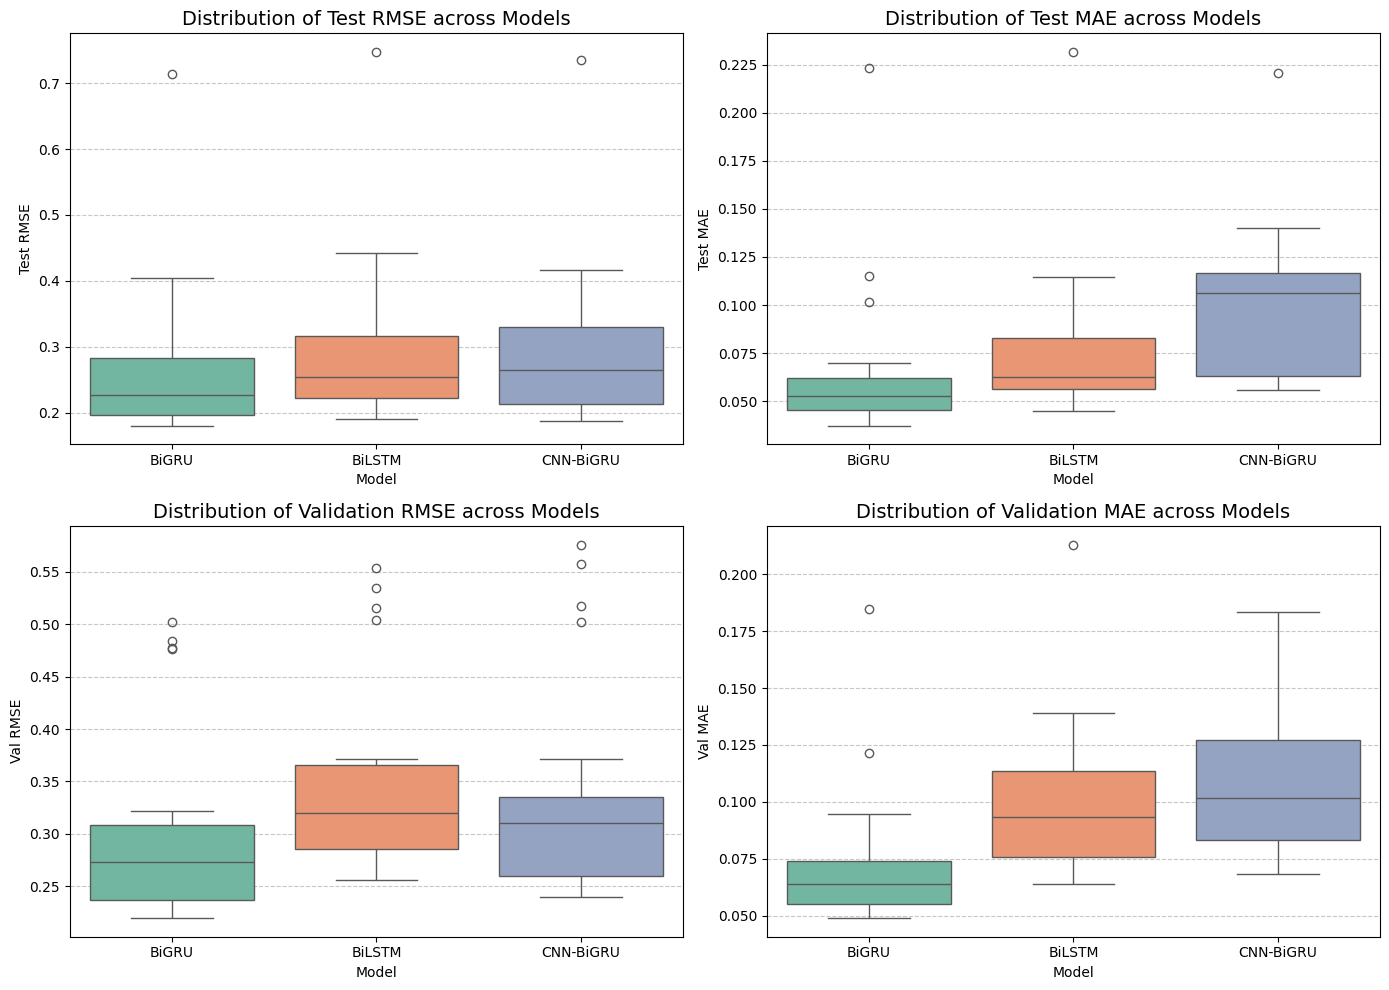

In [ ]:
# Plot both boxplots side by side
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Test RMSE
sns.boxplot(data=test_rmse_melted, x='Model', y='Test RMSE', palette='Set2', ax=axs[0, 0])
axs[0, 0].set_title("Distribution of Test RMSE across Models", fontsize=14)
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Test MAE
sns.boxplot(data=test_mae_melted, x='Model', y='Test MAE', palette='Set2', ax=axs[0, 1])
axs[0, 1].set_title("Distribution of Test MAE across Models", fontsize=14)
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Val RMSE
sns.boxplot(data=val_rmse_melted, x='Model', y='Val RMSE', palette='Set2', ax=axs[1, 0])
axs[1, 0].set_title("Distribution of Validation RMSE across Models", fontsize=14)
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Val MAE
sns.boxplot(data=val_mae_melted, x='Model', y='Val MAE', palette='Set2', ax=axs[1, 1])
axs[1, 1].set_title("Distribution of Validation MAE across Models", fontsize=14)
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**3.Heat Map**

<ipython-input-40-1b59822626e5>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  best_model_encoded = best_model_df.replace({


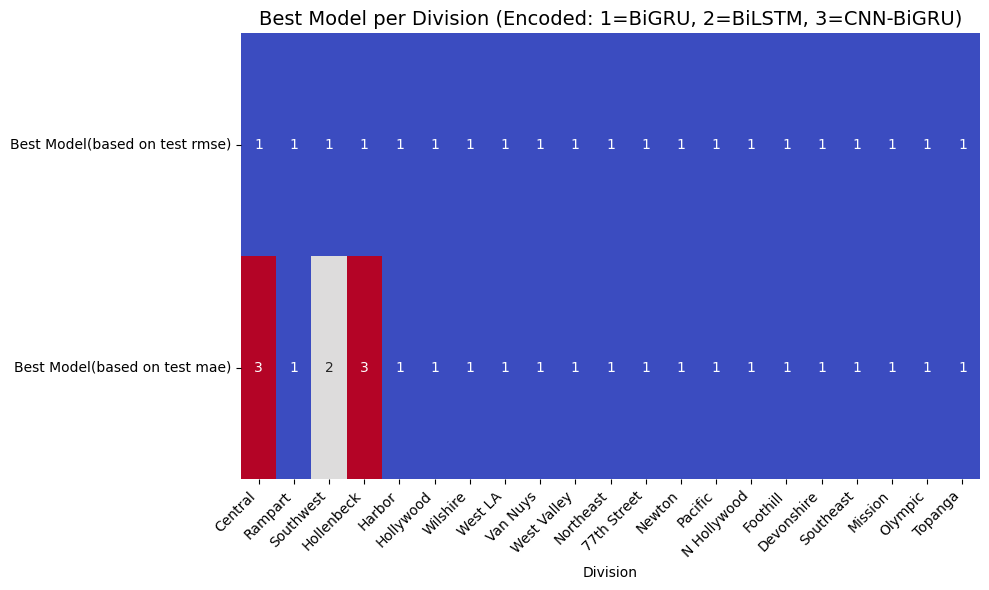

In [ ]:
# Create a DataFrame to visualize which model performed best per division
best_model_df = test_metrics_df[['Division', 'Best Model(based on test rmse)', 'Best Model(based on test mae)']]

best_model_encoded = best_model_df.replace({
    'bi_gru': 1,
    'bi_lstm': 2,
    'cnn_bi_gru': 3
})

plt.figure(figsize=(10, 6))
sns.heatmap(best_model_encoded.set_index('Division').T, cmap='coolwarm', annot=True, cbar=False)
plt.title("Best Model per Division (Encoded: 1=BiGRU, 2=BiLSTM, 3=CNN-BiGRU)", fontsize=14)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**4.Line Plot**

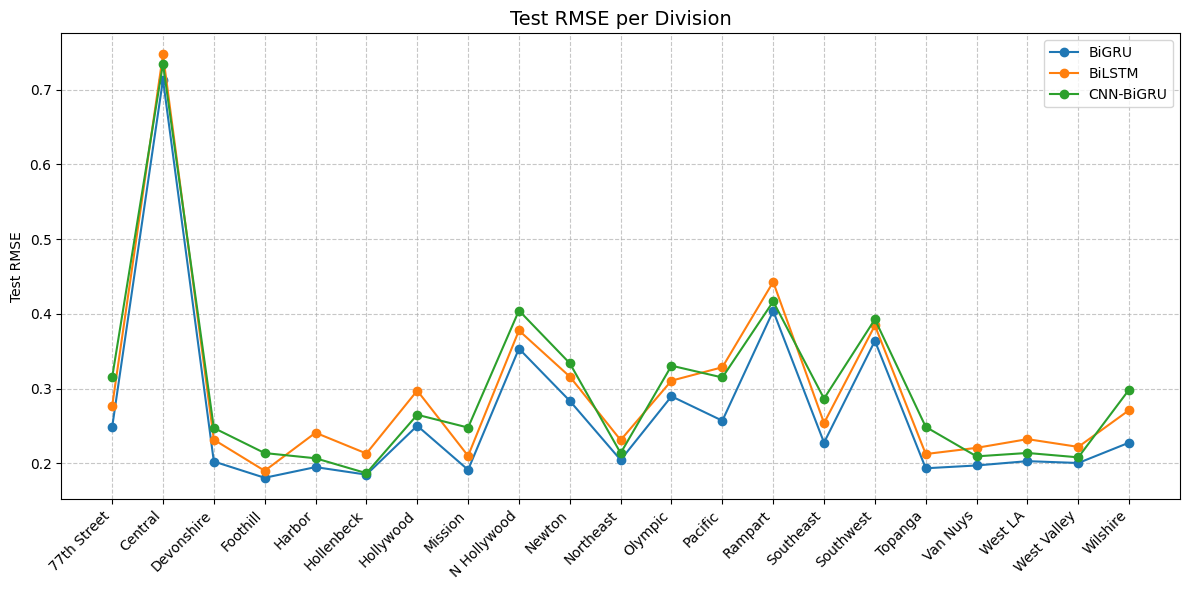

In [ ]:
test_rmse_df_sorted = test_rmse_df.sort_values("Division")

plt.figure(figsize=(12,6))
for model in ['BiGRU', 'BiLSTM', 'CNN-BiGRU']:
    plt.plot(test_rmse_df_sorted['Division'], test_rmse_df_sorted[model], marker='o', label=model)

plt.title("Test RMSE per Division", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test RMSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
